In [3]:
# locate the root folder
CODE_DIR = '/home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/pSp_encoder_constructive/'

import os
os.chdir(f'{CODE_DIR}')

notebook_path = os.getcwd()
print('Current working directory is:', '\n', notebook_path) 

import time
import math
from typing import List


import torch
import torch.nn.functional as F
import torch.utils.data
from torch import nn
import numpy as np
import matplotlib.pyplot as plt



Current working directory is: 
 /home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/pSp_encoder_constructive


In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim

# # Define the output_regularization function (as before)
# def output_regularization(output, reg_type='L1', lambda_reg=0.1, a=3.7, gamma=3, tau=0.5, epsilon=1e-8):
#     abs_output = torch.abs(output)

#     if reg_type == 'L1':
#         regularization_fn = torch.abs
#     elif reg_type == 'adaptive':
#         regularization_fn = lambda x: lambda_reg * (x / (torch.abs(x) + epsilon))
#     elif reg_type == 'thresholded':
#         regularization_fn = lambda x: torch.where(torch.abs(x) < tau, torch.abs(x), torch.tensor(0.0, device=x.device))
#     elif reg_type == 'SCAD':
#         def scad_penalty(x):
#             penalty = torch.zeros_like(x)
#             mask1 = abs_output <= lambda_reg
#             penalty[mask1] = lambda_reg * abs_output[mask1]
#             mask2 = (abs_output > lambda_reg) & (abs_output <= a * lambda_reg)
#             penalty[mask2] = (-x[mask2]**2 + 2 * a * lambda_reg * abs_output[mask2] - lambda_reg**2) / (2 * (a - 1))
#             return penalty
#         regularization_fn = scad_penalty
#     elif reg_type == 'MCP':
#         def mcp_penalty(x):
#             penalty = torch.zeros_like(x)
#             mask1 = abs_output <= gamma * lambda_reg
#             penalty[mask1] = lambda_reg * abs_output[mask1] - (x[mask1]**2) / (2 * gamma)
#             return penalty
#         regularization_fn = mcp_penalty
#     else:
#         raise ValueError(f"Invalid regularization type: '{reg_type}'.")

#     penalty = regularization_fn(output)
#     return output - penalty  # Adjust output by subtracting penalty

# # Define a simple neural network
# class SimpleNet(nn.Module):
#     def __init__(self):
#         super(SimpleNet, self).__init__()
#         self.fc = nn.Linear(10, 10)  # A single linear layer

#     def forward(self, x):
#         return self.fc(x)

# # Initialize network, optimizer, and sample input
# net = SimpleNet()
# optimizer = optim.SGD(net.parameters(), lr=0.01)
# criterion = nn.MSELoss()

# # Sample input and target output
# input_data = torch.randn(1, 10)
# target = torch.randn(1, 10)

# # List of regularization types to test
# regularization_types = ['L1', 'adaptive', 'thresholded', 'SCAD', 'MCP']

# # Iterate through each regularization type
# for reg_type in regularization_types:
#     # Reset the network to initial state for each test
#     net = SimpleNet()
#     optimizer = optim.SGD(net.parameters(), lr=0.01)

#     # Perform one forward pass
#     output = net(input_data)

#     # Apply regularization to the output
#     regularized_output = output_regularization(output, reg_type=reg_type, lambda_reg=0.1)

#     # Calculate loss between the regularized output and target
#     loss = criterion(regularized_output, target)

#     # Perform backward pass and update weights
#     optimizer.zero_grad()
#     loss.backward()
#     optimizer.step()

#         # Output each original and adjusted tensor
#     output_dict = {
#         "Original ": output.abs(),
#         "L1 Lasso ": l1_adjusted,
#         "Adaptive ": adaptive_adjusted,
#         "Threshold": thresholded_adjusted,
#         "SCAD     ": scad_adjusted,
#         "MCP      ": mcp_adjusted
#     }

#     # Print the results for this regularization type
#     print(f"Regularization Type: {reg_type}")
#     print("Original Output:\n", output.detach().numpy())
#     print("Regularized Output:\n", regularized_output.detach().numpy())
#     # print("Updated Weights (after one iteration):")
#     # for name, param in net.named_parameters():
#     #     print(name, param.data.detach().numpy())
#     # print("\n" + "="*50 + "\n")
    

Regularization Type: L1
Original Output:
 [[-0.45886192  1.2373613   0.9551555  -1.3711225  -0.00792594 -0.46041158
   1.7998807  -0.6151146  -0.5655407   0.96028024]]
Regularized Output:
 [[-0.91772383  0.          0.         -2.742245   -0.01585189 -0.92082316
   0.         -1.2302293  -1.1310813   0.        ]]
Regularization Type: adaptive
Original Output:
 [[ 0.01523864  0.46734658 -0.4271025  -0.8271669  -0.1181321   1.7357478
   0.4868364  -0.30412722 -0.8234234   1.9368654 ]]
Regularized Output:
 [[-0.08476129  0.36734658 -0.3271025  -0.7271669  -0.01813211  1.6357478
   0.3868364  -0.20412722 -0.72342336  1.8368654 ]]
Regularization Type: thresholded
Original Output:
 [[-0.47016484 -0.7890594  -0.92544794 -0.57223284 -0.07973175 -0.61567855
  -0.7680643  -0.2628439   1.1533959  -0.98331904]]
Regularized Output:
 [[-0.9403297  -0.7890594  -0.92544794 -0.57223284 -0.1594635  -0.61567855
  -0.7680643  -0.5256878   1.1533959  -0.98331904]]
Regularization Type: SCAD
Original Output:

Original : ['0.0500', '-0.1500', '0.2500', '-0.4500', '0.6500', '-0.8500', '1.0500', '-1.2500']
L1 Lasso : ['0.0500', '0.1500', '0.2500', '0.4500', '0.6500', '0.8500', '1.0500', '1.2500']
Adaptive : ['1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000', '1.0000']
Threshold: ['0.0100', '0.0300', '0.0500', '0.0900', '0.0000', '0.0000', '0.0000', '0.0000']
SCAD     : ['0.0100', '0.0300', '0.0495', '0.0784', '0.0925', '0.0000', '0.0000', '0.0000']
MCP      : ['0.0096', '0.0263', '0.0396', '0.0562', '0.0000', '0.0000', '0.0000', '0.0000']


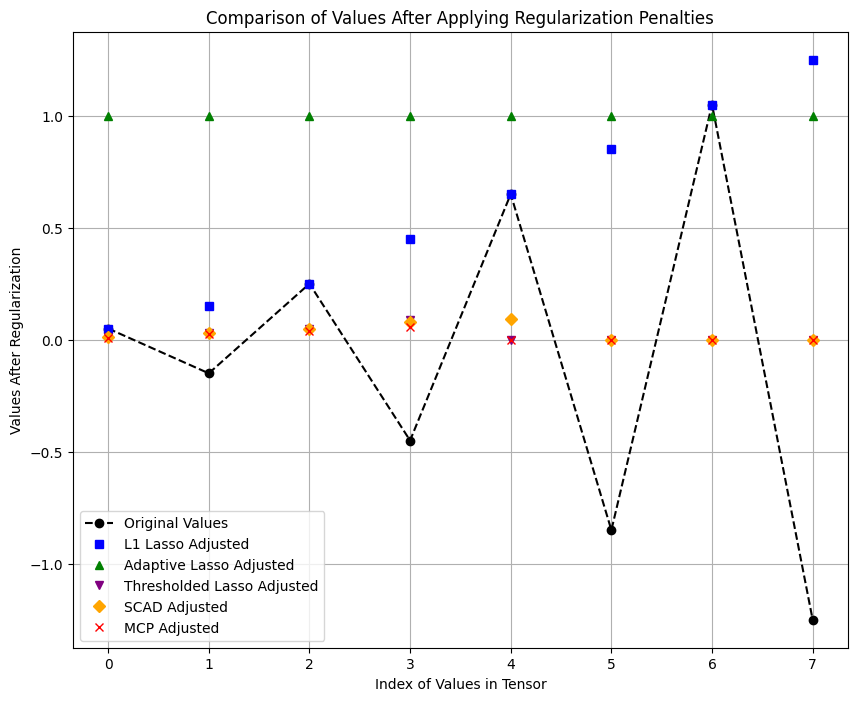

In [61]:
import torch
import matplotlib.pyplot as plt

# Define the output_regularization function as before
def output_regularization(output, reg_type='L1', lambda_reg=0.1, a=3.7, gamma=3, tau=0.5, epsilon=1e-8):
    abs_output = torch.abs(output)

    if reg_type == 'L1':
        # Standard L1 regularization
        regularization_fn = lambda x: torch.abs(x)

    elif reg_type == 'adaptive':
        # Adaptive L1 regularization
        #regularization_fn = lambda x: lambda_reg * (x / (torch.abs(x) + epsilon))
        regularization_fn = lambda x: (1.0 / (torch.abs(x) + epsilon)) * torch.abs(x)

    elif reg_type == 'thresholded':
        # Thresholded Lasso regularization
        regularization_fn = lambda x: lambda_reg * torch.where(torch.abs(x) < tau, torch.abs(x), torch.tensor(0.0, device=x.device))

    elif reg_type == 'SCAD':
        # SCAD regularization
        def scad_penalty(x):
            penalty = torch.zeros_like(x)
            mask1 = abs_output <= lambda_reg
            penalty[mask1] = lambda_reg * abs_output[mask1]
            mask2 = (abs_output > lambda_reg) & (abs_output <= a * lambda_reg)
            penalty[mask2] = (-x[mask2]**2 + 2 * a * lambda_reg * abs_output[mask2] - lambda_reg**2) / (2 * (a - 1))
            return penalty
        regularization_fn = scad_penalty

    elif reg_type == 'MCP':
        # MCP regularization
        def mcp_penalty(x):
            penalty = torch.zeros_like(x)
            mask1 = abs_output <= gamma * lambda_reg
            penalty[mask1] = lambda_reg * abs_output[mask1] - (x[mask1]**2) / (2 * gamma)
            return penalty
        regularization_fn = mcp_penalty

    else:
        raise ValueError(f"Invalid regularization type: '{reg_type}'.")

    # Calculate the penalty for each element without summing
    penalty = regularization_fn(output)
    return penalty  # Return the element-wise penalty tensor

# Sample 1x10 tensor for testing
output = torch.tensor([0.05, -0.15, 0.25, -0.45, 0.65, -0.85, 1.05, -1.25])

# Regularization parameters
lambda_reg = 0.2
a_scad = 3.7
gamma_mcp = 3
tau = 0.5
epsilon = 1e-8

# Compute penalties for each regularization type
l1_penalty = output_regularization(output, reg_type='L1', lambda_reg=lambda_reg)
adaptive_penalty = output_regularization(output, reg_type='adaptive', lambda_reg=lambda_reg, epsilon=epsilon)
thresholded_penalty = output_regularization(output, reg_type='thresholded', lambda_reg=lambda_reg, tau=tau)
scad_penalty = output_regularization(output, reg_type='SCAD', lambda_reg=lambda_reg, a=a_scad)
mcp_penalty = output_regularization(output, reg_type='MCP', lambda_reg=lambda_reg, gamma=gamma_mcp)

# Calculate adjusted values (original - penalty)
l1_adjusted = l1_penalty
adaptive_adjusted = adaptive_penalty
thresholded_adjusted = thresholded_penalty
scad_adjusted = scad_penalty
mcp_adjusted = mcp_penalty

# Output each original and adjusted tensor
output_dict = {
    "Original ": output,
    "L1 Lasso ": l1_adjusted,
    "Adaptive ": adaptive_adjusted,
    "Threshold": thresholded_adjusted,
    "SCAD     ": scad_adjusted,
    "MCP      ": mcp_adjusted
}

# Print each item in output_dict with values formatted to 4 decimal places
for key, value in output_dict.items():
    formatted_values = [f"{v:.4f}" for v in value.numpy()]
    print(f"{key}: {formatted_values}")


#output = torch.randn(15)
x_indices = list(range(len(output)))  # Indexes for x-axis
# Display the original and adjusted values for each regularization type in a structured output format


# Plot the adjusted values for each regularization type along with the original values
plt.figure(figsize=(10, 8))
plt.plot(x_indices, output.numpy(), label='Original Values', marker='o', linestyle='--', color='black')
plt.plot(x_indices, l1_adjusted.numpy(), label='L1 Lasso Adjusted', marker='s', linestyle='None', color='blue')
plt.plot(x_indices, adaptive_adjusted.numpy(), label='Adaptive Lasso Adjusted', marker='^', linestyle='None', color='green')
plt.plot(x_indices, thresholded_adjusted.numpy(), label='Thresholded Lasso Adjusted', marker='v', linestyle='None', color='purple')
plt.plot(x_indices, scad_adjusted.numpy(), label='SCAD Adjusted', marker='D', linestyle='None', color='orange')
plt.plot(x_indices, mcp_adjusted.numpy(), label='MCP Adjusted', marker='x', linestyle='None', color='red')

# Labels and legend
plt.xlabel('Index of Values in Tensor')
plt.ylabel('Values After Regularization')
plt.title('Comparison of Values After Applying Regularization Penalties')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import torch

# Define the output_regularization function as before
def output_regularization(output, reg_type='L1', lambda_reg=0.1, a=3.7, gamma=3, tau=0.5, epsilon=1e-8):
    abs_output = torch.abs(output)

    if reg_type == 'L1':
        # Standard L1 regularization
        regularization_fn = torch.abs

    elif reg_type == 'adaptive':
        # Adaptive L1 regularization
        regularization_fn = lambda x: lambda_reg * (x / (torch.abs(x) + epsilon))

    elif reg_type == 'thresholded':
        # Thresholded Lasso regularization
        regularization_fn = lambda x: torch.where(torch.abs(x) < tau, torch.abs(x), torch.tensor(0.0, device=x.device))

    elif reg_type == 'SCAD':
        # SCAD regularization
        def scad_penalty(x):
            penalty = torch.zeros_like(x)
            mask1 = abs_output <= lambda_reg
            penalty[mask1] = lambda_reg * abs_output[mask1]
            mask2 = (abs_output > lambda_reg) & (abs_output <= a * lambda_reg)
            penalty[mask2] = (-x[mask2]**2 + 2 * a * lambda_reg * abs_output[mask2] - lambda_reg**2) / (2 * (a - 1))
            return penalty
        regularization_fn = scad_penalty

    elif reg_type == 'MCP':
        # MCP regularization
        def mcp_penalty(x):
            penalty = torch.zeros_like(x)
            mask1 = abs_output <= gamma * lambda_reg
            penalty[mask1] = lambda_reg * abs_output[mask1] - (x[mask1]**2) / (2 * gamma)
            return penalty
        regularization_fn = mcp_penalty

    else:
        raise ValueError(f"Invalid regularization type: '{reg_type}'.")

    # Calculate the penalty for each element without summing
    penalty = regularization_fn(output)
    return penalty  # Return the element-wise penalty tensor

# Sample 1x10 tensor for testing
output = torch.tensor([0.05, -0.15, 0.25, -0.45, 0.65, -0.85, 1.05, -1.25, 1.5, -2.0])

# Regularization parameters
lambda_reg = 0.3
a_scad = 3.7
gamma_mcp = 3
tau = 0.5
epsilon = 1e-8

# Compute penalties for each regularization type
l1_penalty = output_regularization(output, reg_type='L1', lambda_reg=lambda_reg)
adaptive_penalty = output_regularization(output, reg_type='adaptive', lambda_reg=lambda_reg, epsilon=epsilon)
thresholded_penalty = output_regularization(output, reg_type='thresholded', lambda_reg=lambda_reg, tau=tau)
scad_penalty = output_regularization(output, reg_type='SCAD', lambda_reg=lambda_reg, a=a_scad)
mcp_penalty = output_regularization(output, reg_type='MCP', lambda_reg=lambda_reg, gamma=gamma_mcp)

# Calculate adjusted values (original - penalty)
l1_adjusted = output - l1_penalty
adaptive_adjusted = output - adaptive_penalty
thresholded_adjusted = output - thresholded_penalty
scad_adjusted = output - scad_penalty
mcp_adjusted = output - mcp_penalty

# Output each original and adjusted tensor
output_dict = {
    "Original Output": output,
    "L1 Lasso Adjusted": l1_adjusted,
    "Adaptive Lasso Adjusted": adaptive_adjusted,
    "Thresholded Lasso Adjusted": thresholded_adjusted,
    "SCAD Adjusted": scad_adjusted,
    "MCP Adjusted": mcp_adjusted
}

output_dict


Original output: tensor([[ 4.6088,  0.1054,  1.1905,  0.6901,  0.8244,  1.1419,  2.4956,  2.5799,
         -5.4996,  1.4785]])

Penalties for each regularization type:
L1 Lasso penalty (element-wise): tensor(20.6147)
Adaptive Lasso penalty (element-wise): tensor(10.)
Thresholded Lasso penalty (element-wise): tensor(0.1054)
SCAD penalty (element-wise): tensor(0.4069)
MCP penalty (element-wise): tensor(0.2915)


In [6]:
import torch

# Sample tensor to test the regularization functions
output = torch.tensor([0.01, -0.1, 0.3, -0.5, 1.0, -1.5, 2.0, -2.5, 3.0, -3.5])
print("Original tensor:", output)

# Regularization parameters
lambda_reg = 0.3  # Scaling factor for the first function
epsilon = 1e-8    # Small constant to prevent division by zero

# First function: Adaptive shrinkage with lambda_reg scaling
regularization_fn_1 = lambda x: lambda_reg * (x / (torch.abs(x) + epsilon))

# Second function: Adaptive shrinkage without lambda_reg scaling
regularization_fn_2 = lambda x: (1.0 / (torch.abs(x) + epsilon)) * torch.abs(x)

# Apply each regularization function
penalty_1 = regularization_fn_1(output)
penalty_2 = regularization_fn_2(output)

# Display the results
print("\nFirst Function (with lambda_reg scaling):")
print(penalty_1)

print("\nSecond Function (without lambda_reg scaling):")
print(penalty_2)


Original tensor: tensor([ 0.0100, -0.1000,  0.3000, -0.5000,  1.0000, -1.5000,  2.0000, -2.5000,
         3.0000, -3.5000])

First Function (with lambda_reg scaling):
tensor([ 0.3000, -0.3000,  0.3000, -0.3000,  0.3000, -0.3000,  0.3000, -0.3000,
         0.3000, -0.3000])

Second Function (without lambda_reg scaling):
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from models.stylegan2_mlp import MappingNetwork_th, MappingNetwork_cs

def visualize_latentmat(mat_roi):

    yticks=[0, 17]

    plt.figure(figsize=(15,10))
    ax = plt.gca()
    im = ax.matshow(mat_roi)
    ax.set_yticks(yticks)    
    # create an axes on the right side of ax. The width of cax will be 5%
    # of ax and the padding between cax and ax will be fixed at 0.05 inch.
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.5)
    
    plt.colorbar(im, cax=cax)
    
# Custom loss function with Row-wise or Column-wise L1 regularization on the output matrix
def custom_loss(output, target, lambda_l1, reg_type='row'):
    """Compute total loss including MSE and row/column-wise L1 regularization."""
    # Compute original loss (e.g., MSE)
    mse_loss = nn.MSELoss()(output, target)

    # Apply row-wise or column-wise L1 regularization
    if reg_type == 'row':
        # Row-wise L1 penalty: sum over columns, apply L1 norm to each row
        l1_penalty = torch.sum(torch.abs(output).sum(dim=2))  # Summing across columns (width)
    elif reg_type == 'column':
        # Column-wise L1 penalty: sum over rows, apply L1 norm to each column
        l1_penalty = torch.sum(torch.abs(output).sum(dim=1))  # Summing across rows (height)
    elif reg_type == 'elements':
        l1_penalty = torch.sum(torch.abs(output))  # Summing across all elements
    else:
        raise ValueError(f"Unknown regularization type: {reg_type}. Use 'row' or 'column'.")

    # Total loss: original loss + L1 penalty
    total_loss = mse_loss + lambda_l1 * l1_penalty
    return total_loss

# Training step function
def train_step(model, optimizer, data, target, lambda_l1, reg_type='row'):
    """Perform a single training step."""
    optimizer.zero_grad()  # Zero the gradients

    # Forward pass
    _, output = model(data, lambda_l1)

    # Compute custom loss with row/column-wise L1 regularization
    loss = custom_loss(output, target, lambda_l1, reg_type)

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss.item(), output

# Simulated data
data = torch.randn(8, 18, 512)  # Batch of input vectors (32 samples, 10 features each)
target = torch.randn(8, 18, 512)  # Random target output with shape (batch_size, height, width)
lambda_l1 = 0.0001  # L1 regularization parameter

# Initialize model, optimizer, and parameters
model = MappingNetwork_cs_th(512,8)

optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training loop with row-wise regularization
print("Training with Row-wise L1 Regularization:")
for epoch in range(1000):  # Adjust the number of epochs as needed
    loss, output = train_step(model, optimizer, data, target, lambda_l1, reg_type='row')
    #print(f"Epoch {epoch + 1}, Total Loss: {loss:.4f}, Output Mean: {output.mean().item()}")

# cs_orn_roi1 = output[0,:,:].cpu().detach().numpy() 
# visualize_latentmat(cs_orn_roi1)

# # Training loop with column-wise regularization
# print("\nTraining with Column-wise L1 Regularization:")
# for epoch in range(100):  # Adjust the number of epochs as needed
#     loss, output = train_step(model, optimizer, data, target, lambda_l1, reg_type='column')
#     #print(f"Epoch {epoch + 1}, Total Loss: {loss:.4f}, Output Mean: {output.mean().item()}")

cs_orn_roi1 = output[0,:,:50].cpu().detach().numpy() 
visualize_latentmat(cs_orn_roi1)

# Check how many values are exactly zero in the final output
num_zeroed = (output == 0).sum().item()
print(f"Number of outputs exactly zero: {num_zeroed} out of {output.numel()}")


In [ ]:
output

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define a simple neural network model with thresholding in the forward pass
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc1 = nn.Linear(10, 20)
        self.fc2 = nn.Linear(20, 20)  # Outputs a 12-dimensional vector

    def forward(self, x, lambda_l1):
        x = torch.relu(self.fc1(x))  # Using ReLU activation
        output = self.fc2(x)
        # Apply soft thresholding directly to the output
        output = self.soft_threshold(output, lambda_l1)
        return output

    @staticmethod
    def soft_threshold(x, threshold):
        """Apply soft thresholding to the output."""
        return torch.sign(x) * torch.maximum(torch.abs(x) - threshold, torch.tensor(0.0, device=x.device))

# Custom loss function with Lasso regularization
def lasso_loss(output, target, lambda_l1):
    """Compute total loss including MSE and Lasso regularization."""
    # Compute original loss (e.g., MSE)
    mse_loss = nn.MSELoss()(output, target)

    # Compute L1 norm (for regularization)
    l1_penalty = torch.sum(torch.abs(output))  # Use thresholded output directly

    # Total loss: original loss + L1 penalty
    total_loss = mse_loss + lambda_l1 * l1_penalty
    return total_loss

# Training step function
def train_step(model, optimizer, data, target, lambda_l1):
    """Perform a single training step."""
    optimizer.zero_grad()  # Zero the gradients

    # Forward pass with thresholding
    output = model(data, lambda_l1)

    # Compute custom loss
    loss = lasso_loss(output, target, lambda_l1)

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss.item(), output

# Initialize model, optimizer, and parameters
model = SimpleModel()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Simulated data
data = torch.randn(32, 10)  # Batch of input vectors
target = torch.randn(32, 20) * 0.5  # Random target outputs (scaled for demonstration)
lambda_l1 = 0.01  # L1 regularization parameter

# Training loop
for epoch in range(200):  # Increase epochs for better training
    loss, output = train_step(model, optimizer, data, target, lambda_l1)
    print(f"Epoch {epoch + 1}, Total Loss: {loss:.4f}, Output Mean: {output.mean().item()}")

# Check how many values are exactly zero in the final output
num_zeroed = (output == 0).sum().item()
print(f"Number of outputs exactly zero: {num_zeroed} out of {output.numel()}")


In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim

# # Define a simple neural network model with a 3D output (batch x height x width)
# class SimpleModel(nn.Module):
#     def __init__(self):
#         super(SimpleModel, self).__init__()
#         self.fc1 = nn.Linear(10, 128)
#         self.fc2 = nn.Linear(128, 32 * 32)  # Outputs a 1024-dimensional vector (e.g., 32x32 image)

#     def forward(self, x):
#         x = torch.relu(self.fc1(x))
#         output = self.fc2(x)
#         output = output.view(-1, 32, 32)  # Reshape to (batch_size, height, width)
#         output = self.soft_threshold(output, lambda_l1)
#         return output
#     @staticmethod
#     def soft_threshold(x, threshold):
#         """Apply soft thresholding to the output."""
#         return torch.sign(x) * torch.maximum(torch.abs(x) - threshold, torch.tensor(0.0, device=x.device))
    
    
# # Custom loss function with Row-wise or Column-wise L1 regularization on the output matrix
# def custom_loss(output, target, lambda_l1, reg_type='row'):
#     """Compute total loss including MSE and row/column-wise L1 regularization."""
#     # Compute original loss (e.g., MSE)
#     mse_loss = nn.MSELoss()(output, target)

#     # Apply row-wise or column-wise L1 regularization
#     if reg_type == 'row':
#         # Row-wise L1 penalty: sum over columns, apply L1 norm to each row
#         l1_penalty = torch.sum(torch.abs(output).sum(dim=2))  # Summing across columns (width)
#     elif reg_type == 'column':
#         # Column-wise L1 penalty: sum over rows, apply L1 norm to each column
#         l1_penalty = torch.sum(torch.abs(output).sum(dim=1))  # Summing across rows (height)
#     elif reg_type == 'elements':
#         l1_penalty = torch.sum(torch.abs(output))  # Summing across all elements
#     else:
#         raise ValueError(f"Unknown regularization type: {reg_type}. Use 'row' or 'column'.")

#     # Total loss: original loss + L1 penalty
#     total_loss = mse_loss + lambda_l1 * l1_penalty
#     return total_loss

# # Training step function
# def train_step(model, optimizer, data, target, lambda_l1, reg_type='row'):
#     """Perform a single training step."""
#     optimizer.zero_grad()  # Zero the gradients

#     # Forward pass
#     output = model(data)

#     # Compute custom loss with row/column-wise L1 regularization
#     loss = custom_loss(output, target, lambda_l1, reg_type)

#     # Backpropagation
#     loss.backward()
#     optimizer.step()

#     return loss.item(), output

# # Initialize model, optimizer, and parameters
# model = SimpleModel()
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# # Simulated data
# data = torch.randn(32, 10)  # Batch of input vectors (32 samples, 10 features each)
# target = torch.randn(32, 32, 32) * 0.5  # Random target output with shape (batch_size, height, width)
# lambda_l1 = 0.01  # L1 regularization parameter

# # Training loop with row-wise regularization
# print("Training with Row-wise L1 Regularization:")
# for epoch in range(100):  # Adjust the number of epochs as needed
#     loss, output = train_step(model, optimizer, data, target, lambda_l1, reg_type='row')
#     #print(f"Epoch {epoch + 1}, Total Loss: {loss:.4f}, Output Mean: {output.mean().item()}")

# cs_orn_roi1 = output[0,:,:].cpu().detach().numpy() 
# visualize_latentmat(cs_orn_roi1)

# # Training loop with column-wise regularization
# print("\nTraining with Column-wise L1 Regularization:")
# for epoch in range(100):  # Adjust the number of epochs as needed
#     loss, output = train_step(model, optimizer, data, target, lambda_l1, reg_type='column')
#     #print(f"Epoch {epoch + 1}, Total Loss: {loss:.4f}, Output Mean: {output.mean().item()}")

# cs_orn_roi1 = output[0,:,:].cpu().detach().numpy() 
# visualize_latentmat(cs_orn_roi1)

# # Check how many values are exactly zero in the final output
# num_zeroed = (output == 0).sum().item()
# print(f"Number of outputs exactly zero: {num_zeroed} out of {output.numel()}")


In [ ]:
cs_orn_roi1

In [ ]:
# # Example model
# class SimpleModel(nn.Module):
#     def __init__(self):
#         super(SimpleModel, self).__init__()
#         self.fc = nn.Linear(10, 5)

#     def forward(self, x):
#         return self.fc(x)

# # L1 Regularization function
# def l1_regularization(model, lambda_l1):
#     l1_norm = torch.tensor(0.0, requires_grad=True)
#     for param in model.parameters():
#         l1_norm = l1_norm + torch.sum(torch.abs(param))
#     return lambda_l1 * l1_norm

# # Soft-thresholding function (already defined above)
# def soft_thresholding(param, threshold):
#     return torch.sign(param) * torch.max(torch.zeros_like(param), torch.abs(param) - threshold)

# # Training loop with Adam and Lasso
# def train(model, optimizer, criterion, train_loader, lambda_l1, num_epochs=100):
#     model.train()
    
#     for epoch in range(num_epochs):
#         epoch_loss = 0.0
#         for data, target in train_loader:
#             # Forward pass
#             outputs = model(data)
#             loss = criterion(outputs, target)
#             #print(data.shape)
#             # Add L1 regularization term
#             l1_penalty = l1_regularization(model, lambda_l1)
#             total_loss = loss + l1_penalty

#             # Backward pass and optimization
#             optimizer.zero_grad()
#             total_loss.backward()
#             optimizer.step()

#             # Soft-thresholding step
#             with torch.no_grad():
#                 for param in model.parameters():
#                     param.data = soft_thresholding(param.data, lambda_l1 * optimizer.param_groups[0]['lr'])

#             epoch_loss += total_loss.item()
    
#         #print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss}')
#     #print(outputs)
# # Example usage
# model = SimpleModel()
# optimizer = optim.Adam(model.parameters(), lr=0.001)
# criterion = nn.MSELoss()  # Example loss function

# # Simulate a dummy dataset loader
# train_loader = [(torch.randn(15, 10), torch.randn(15, 5)) for _ in range(100)]



In [ ]:
# # Set lambda for Lasso (L1 regularization)
# lambda_l1 = 0.01

# # Train the model
# train(model, optimizer, criterion, train_loader, lambda_l1, num_epochs=10)

# test_input = torch.randn(2, 10)
# print('weight', model.fc.state_dict()['weight'])
# with torch.no_grad():
#     output = model(test_input)
#     print('output',output)

In [ ]:
# # Initialize model, optimizer, and criterion
# model = SimpleModel()
# optimizer = optim.Adam(model.parameters(), lr=0.001)
# criterion = nn.MSELoss()

# # Simulated data
# data = torch.randn(32, 10)  # Batch of input vectors
# target = torch.randn(32, 12)  # Target output
# lambda_l1 = 0.01  # Lasso regularization strength

# # Example training loop
# for epoch in range(10):
#     loss = train_step(model, optimizer, criterion, data, target, lambda_l1)
#     print(f"Epoch {epoch + 1}, Total Loss: {loss:.4f}")


In [ ]:
# # class MLP(torch.nn.Module):
# #     def __init__(self):
# #         super(MLP, self).__init__()
# #         self.linear1 = torch.nn.Linear(128, 32)
# #         self.linear2 = torch.nn.Linear(32, 16)
# #         self.linear3 = torch.nn.Linear(16, 2)

# #     def forward(self, x):
# #         layer1_out = F.relu(self.linear1(x))
# #         layer2_out = F.relu(self.linear2(layer1_out))
# #         out = self.linear3(layer2_out)
# #         return out, layer1_out, layer2_out

# class MLP(torch.nn.Module):
#     def __init__(self):
#         super(MLP, self).__init__()
#         self.linear1 = torch.nn.Linear(128, 32)
#         self.linear2 = torch.nn.Linear(32, 16)
#         self.linear3 = torch.nn.Linear(16, 2)

#     def forward(self, x):
#         layer1_out = self.linear1(x)
#         layer2_out = self.linear2(layer1_out)
#         out = self.linear3(layer2_out)
#         return out, layer1_out, layer2_out

# seed = 4516

# batchsize = 4
# lambda1, lambda2 = 0.1, 0.00

# model = MLP()
# optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

# # usually following code is looped over all batches 
# # but let's just do a dummy batch for brevity
# for i in range (2000):

#     inputs = Variable(torch.rand(batchsize, 128))
#     targets = Variable(torch.ones(batchsize).long())

#     optimizer.zero_grad()
#     outputs, layer1_out, layer2_out = model(inputs)
#     cross_entropy_loss = F.cross_entropy(outputs, targets)

#     #l1_regularization = lambda1 *sum([torch.abs(p).sum() for p in model.linear1.parameters()])

#     all_linear1_params = torch.cat([x.view(-1) for x in model.linear1.parameters()])
#     all_linear2_params = torch.cat([x.view(-1) for x in model.linear2.parameters()])
#     l1_regularization = lambda1 * torch.norm(all_linear1_params, 1)
#     l2_regularization = lambda2 * torch.norm(all_linear2_params, 2)
#     # print(l1loss)
#     #print(l1_regularization)

#     loss = cross_entropy_loss + l1_regularization #+ l2_regularization
#     loss.backward()
#     optimizer.step()



In [ ]:
# layer1_out
# print(l1_regularization)

In [ ]:
# import torch
# from torch.utils.data import DataLoader, TensorDataset
# from sklearn.model_selection import train_test_split
# import numpy as np
# import torch.nn as nn
# import torch.optim as optim
# import matplotlib.pyplot as plt

# # Set seed for reproducibility
# np.random.seed(0)
# torch.manual_seed(0)

# # Create a synthetic dataset
# X = np.random.randn(1000, 10).astype(np.float32)
# y = (np.random.randn(1000) > 0).astype(np.float32)

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
# test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# # Define the neural network model
# class SimpleNN(nn.Module):
#     def __init__(self):
#         super(SimpleNN, self).__init__()
#         self.fc1 = nn.Linear(10, 50)
#         self.fc2 = nn.Linear(50, 1)

#     def forward(self, x):
#         x = torch.relu(self.fc1(x))
#         x = self.fc2(x)
#         return x

# # Define the training function with regularization
# def train_model(model, criterion, optimizer, train_loader, regularization_type=None, lambda_reg=0.01, epochs=20):
#     epoch_losses = []
    
#     for epoch in range(epochs):
#         model.train()
#         running_loss = 0.0
        
#         for inputs, targets in train_loader:
#             optimizer.zero_grad()
#             outputs = model(inputs)
#             loss = criterion(outputs.squeeze(), targets)
            
#             # Apply L1 regularization
#             if regularization_type == 'L1':
#                 l1_norm = sum(p.abs().sum() for p in model.parameters())
#                 loss += lambda_reg * l1_norm
            
#             # Apply L2 regularization
#             elif regularization_type == 'L2':
#                 l2_norm = sum(p.pow(2).sum() for p in model.parameters())
#                 loss += lambda_reg * l2_norm
            
#             loss.backward()
#             optimizer.step()
            
#             running_loss += loss.item() * inputs.size(0)
        
#         epoch_loss = running_loss / len(train_loader.dataset)
#         epoch_losses.append(epoch_loss)
#         print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")
    
#     return epoch_losses

# # # Define the evaluation function
# # def evaluate_model(model, test_loader):
# #     model.eval()
# #     correct = 0
# #     total = 0
    
# #     with torch.no_grad():
# #         for inputs, targets in test_loader:
# #             outputs = model(inputs)

# #             predicted = (outputs.squeeze() > 0.5).float()
# #             total += targets.size(0)
# #             correct += (predicted == targets).sum().item()
    
# #     accuracy = correct / total
# #     print(f"Accuracy: {accuracy:.4f}")
# #     return accuracy

# # # Plot loss over epochs
# # def plot_training_loss(losses, title):
# #     plt.figure(figsize=(10, 5))
# #     plt.plot(range(1, len(losses) + 1), losses, marker='o')
# #     plt.title(title)
# #     plt.xlabel('Epochs')
# #     plt.ylabel('Loss')
# #     plt.grid(True)
# #     plt.show()

# # Training and evaluating with L1 regularization
# print("Training with L1 Regularization:")
# model = SimpleNN()
# criterion = nn.BCEWithLogitsLoss()
# optimizer = optim.SGD(model.parameters(), lr=0.01)
# l1_losses = train_model(model, criterion, optimizer, train_loader, regularization_type='L1', lambda_reg=1, epochs=1000)


# # evaluate_model(model, test_loader)
# # plot_training_loss(l1_losses, 'Training Loss with L1 Regularization')

# # # Reinitialize model, optimizer, and train with L2 regularization
# # print("\nTraining with L2 Regularization:")
# # model = SimpleNN()
# # optimizer = optim.SGD(model.parameters(), lr=0.01)
# # l2_losses = train_model(model, criterion, optimizer, train_loader, regularization_type='L2', lambda_reg=0.01)
# # evaluate_model(model, test_loader)
# # plot_training_loss(l2_losses, 'Training Loss with L2 Regularization')


In [ ]:
# import sklearn.linear_model as linear_model
# import copy
# class Lasso(nn.Module):
#     "Lasso for compressing dictionary"
#     def __init__(self, input_size):
#         super(Lasso, self).__init__()
#         self.linear = nn.Linear(input_size, 1, bias=False)
#     def forward(self, x):
#         out = self.linear(x)
#         return out

# def soft_th(X,threshold = 5):
#      return np.sign(X) * np.maximum((np.abs(X) - threshold), np.zeros(X.shape))

# def torch_soft_operator(X,threshold = 0.1):
#     np_X = X.numpy()
#     tmp = np.sign(np_X) * np.maximum((np.abs(np_X) - threshold), np.zeros(np_X.shape))
#     return torch.from_numpy(tmp.astype(np.float32))
# def lasso(x, y, lmbda = 1,lr=0.005, max_iter=2000, tol=1e-4, opt='SGD'):
#     # x = x.detach()
#     # y = y.detach()
    
#     lso = Lasso(x.shape[1])
#     criterion = nn.MSELoss(reduction='mean')
#     if opt == 'adam':
#         optimizer = torch.optim.Adam(lso.parameters(), lr=lr)
#     elif opt == 'adagrad':
#         optimizer = torch.optim.Adagrad(lso.parameters(), lr=lr)
#     elif opt == "SGD":
#         optimizer = torch.optim.SGD(lso.parameters(), lr=lr)
#     w_prev = torch.tensor(0.)
#     for it in range(max_iter):
#         # lso.linear.zero_grad()
#         optimizer.zero_grad()
#         out = lso(x)
#         fn = criterion(out, y)
#         l1_norm = lmbda * torch.norm(lso.linear.weight, p=1)
#         l1_crit = nn.L1Loss()
#         target = Variable(torch.from_numpy(np.zeros((x.shape[1],1))))

#         loss = 0.5*fn + lmbda * F.l1_loss(lso.linear.weight, target=torch.zeros_like(lso.linear.weight.detach()), size_average=False)
#         loss.backward()
#         optimizer.step()
#         # pdb.set_trace()
#         if it ==0:
#             w = lso.linear.weight.detach()
#         else:
#             with torch.no_grad():
#                 sign_w = torch.sign(w)
#                 ## hard-threshold
# #                 lso.linear.weight[torch.where(torch.abs(lso.linear.weight) <= lmbda*lr)] = 0
#                 ## soft-threshold
# #                 z = lso.linear.weight
# #                 lso.linear.weight[torch.where(z != 0)] = torch.sign(z[torch.where(z != 0)]) * torch.maximum(torch.abs(z[torch.where(z != 0)]) - lr*lmbda,\
# #                                                                                                             torch.zeros_like(z[torch.where(z != 0)]))
#                 w = copy.deepcopy(lso.linear.weight.detach())
#         if it % 500 == 0:
# #             print(target.shape)
#             print(loss.item(),end =" ")
#             print(torch.norm(lso.linear.weight.detach(), p=1),end = " ")
#             print("l1_crit: ",l1_crit(lso.linear.weight.detach(),target),end = " ")
#             print("F L1: ",F.l1_loss(lso.linear.weight.detach(), target=torch.zeros_like(lso.linear.weight.detach()), size_average=False))
#     return lso.linear.weight.detach()


# def soft_threshold(alpha, beta):
#     if beta > alpha:
#         return beta - alpha
#     elif beta < -alpha:
#         return beta + alpha
#     else:
#         return 0
# def gradient(X, y, alpha, beta):
#     n = len(X)
#     ols_term = -2 * np.sum(X*(y - (beta*X))) / n
#     soft_term = soft_threshold(alpha, beta) / n
#     return ols_term + soft_term    

# ## generate data
# np.random.seed(5)
# n = 100
# p = 10
# beta = np.zeros([p]).astype(np.float32)
# beta[0] = 10
# beta[1] =10
# beta[2] = -10
# beta[3] =-10
# X = np.random.rand(n,p).astype(np.float32)
# Y = np.dot(X,beta)
# a = torch.from_numpy(X)
# b = torch.from_numpy(Y.reshape(-1,1))


# ## main 
# penalty = 0.1
# r = lasso(a, b, lmbda = penalty,lr= 0.01,opt='SGD',max_iter = 5000)
# print("\n")
# print("SGD-L1 clipping")
# print(r)
# # print("soft-threshold")
# # print(soft_th(r.numpy(),threshold = penalty))
# # print(soft_threshold(r.numpy(),beta=0.1))


# l = linear_model.Lasso(alpha=penalty, fit_intercept=False)
# l.fit(a, b)
# b_hat = l.predict(a) 
# # l.path(a, b, verbose=True)
# print("sklearn lasso result:")
# print(l.coef_)


# ## SGDRegressor
# sgd = linear_model.SGDRegressor(alpha = penalty,penalty = "l1",learning_rate= "constant", eta0 = 0.01,max_iter = 1000,fit_intercept=False)
# sgd.fit(a,b)
# sgd.coef_

In [ ]:
# for i in range(10):
#     print(soft_threshold(r[0,i], beta=0.1))

In [ ]:
# print(model.fc2.state_dict()['weight'])

In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim

# # Define a simple neural network model with thresholding in the forward pass
# class SimpleModel(nn.Module):
#     def __init__(self):
#         super(SimpleModel, self).__init__()
#         self.fc1 = nn.Linear(10, 20)
#         self.fc2 = nn.Linear(20, 12)  # Outputs a 12-dimensional vector

#     def forward(self, x, lambda_l1):
#         x = torch.relu(self.fc1(x))  # Using ReLU activation
#         output = self.fc2(x)
#         # Apply soft thresholding directly to the output
#         output = self.soft_threshold(output, lambda_l1)
#         return output

#     @staticmethod
#     def soft_threshold(x, threshold):
#         """Apply soft thresholding to the output."""
#         return torch.sign(x) * torch.maximum(torch.abs(x) - threshold, torch.tensor(0.0, device=x.device))

# # Custom loss function with Lasso regularization
# def lasso_loss(output, target, lambda_l1):
#     """Compute total loss including MSE and Lasso regularization."""
#     # Compute original loss (e.g., MSE)
#     mse_loss = nn.MSELoss()(output, target)

#     # Compute L1 norm (for regularization)
#     l1_penalty = torch.sum(torch.abs(output))  # Use thresholded output directly

#     # Total loss: original loss + L1 penalty
#     total_loss = mse_loss + lambda_l1 * l1_penalty
#     return total_loss

# # Training step function
# def train_step(model, optimizer, data, target, lambda_l1):
#     """Perform a single training step."""
#     optimizer.zero_grad()  # Zero the gradients

#     # Forward pass with thresholding
#     output = model(data, lambda_l1)

#     # Compute custom loss
#     loss = lasso_loss(output, target, lambda_l1)

#     # Backpropagation
#     loss.backward()
#     optimizer.step()

#     return loss.item(), output

# # Initialize model, optimizer, and parameters
# model = SimpleModel()
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# # Simulated data
# data = torch.randn(32, 10)  # Batch of input vectors
# target = torch.randn(32, 12) * 0.5  # Random target outputs (scaled for demonstration)
# lambda_l1 = 0.01  # L1 regularization parameter

# # Training loop
# for epoch in range(200):  # Increase epochs for better training
#     loss, output = train_step(model, optimizer, data, target, lambda_l1)
#     print(f"Epoch {epoch + 1}, Total Loss: {loss:.4f}, Output Mean: {output.mean().item()}")

# # Check how many values are exactly zero in the final output
# num_zeroed = (output == 0).sum().item()
# print(f"Number of outputs exactly zero: {num_zeroed} out of {output.numel()}")


In [ ]:
# import torch
# import torch.nn as nn
# import torch.optim as optim

# # Define a simple neural network model with a 3D output (batch x height x width)
# class SimpleModel(nn.Module):
#     def __init__(self):
#         super(SimpleModel, self).__init__()
#         self.fc1 = nn.Linear(10, 128)
#         self.fc2 = nn.Linear(128, 32 * 32)  # Outputs a 1024-dimensional vector (e.g., 32x32 image)

#     def forward(self, x):
#         x = torch.relu(self.fc1(x))
#         output = self.fc2(x)
#         output = output.view(-1, 32, 32)  # Reshape to (batch_size, height, width)
#         return output

# # Custom loss function with L1 regularization on the output matrix
# def lasso_loss(output, target, lambda_l1):
#     """Compute total loss including MSE and Lasso regularization."""
#     # Compute original loss (e.g., MSE)
#     mse_loss = nn.MSELoss()(output, target)

#     # Compute L1 norm of the entire matrix (element-wise L1 regularization)
#     l1_penalty = torch.sum(torch.abs(output))

#     # Total loss: original loss + L1 penalty
#     total_loss = mse_loss + lambda_l1 * l1_penalty
#     return total_loss

# # Training step function
# def train_step(model, optimizer, data, target, lambda_l1):
#     """Perform a single training step."""
#     optimizer.zero_grad()  # Zero the gradients

#     # Forward pass
#     output = model(data)

#     # Compute custom loss
#     loss = lasso_loss(output, target, lambda_l1)

#     # Backpropagation
#     loss.backward()
#     optimizer.step()

#     return loss.item(), output

# # Initialize model, optimizer, and parameters
# model = SimpleModel()
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# # Simulated data
# data = torch.randn(32, 10)  # Batch of input vectors (32 samples, 10 features each)
# target = torch.randn(32, 32, 32) * 0.5  # Random target output with shape (batch_size, height, width)
# lambda_l1 = 0.5  # L1 regularization parameter

# # Training loop
# for epoch in range(200):  # Increase epochs for better training
#     loss, output = train_step(model, optimizer, data, target, lambda_l1)
#     print(f"Epoch {epoch + 1}, Total Loss: {loss:.4f}, Output Mean: {output.mean().item()}")

# # Check how many values are exactly zero in the final output
# num_zeroed = (output == 0).sum().item()
# print(f"Number of outputs exactly zero: {num_zeroed} out of {output.numel()}")


In [ ]:
output = torch.randn(32, 10, 20)

l1_penalty = torch.sum(torch.abs(output))
print(l1_penalty)

l1_penalty = torch.sum(torch.abs(output).sum(dim=2))  # Summing along the width (columns)
print(l1_penalty)

l1_penalty = torch.sum(torch.abs(output).sum(dim=1))
print(l1_penalty)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define a simple neural network model with a 3D output (batch x height x width)
class SimpleModel(nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc1 = nn.Linear(10, 128)
        self.fc2 = nn.Linear(128, 32 * 32)  # Outputs a 1024-dimensional vector (e.g., 32x32 image)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        output = self.fc2(x)
        output = output.view(-1, 32, 32)  # Reshape to (batch_size, height, width)
        return output

# Custom loss function with Row-wise or Column-wise L1 regularization on the output matrix
def custom_loss(output, target, lambda_l1, reg_type='row'):
    """Compute total loss including MSE and row/column-wise L1 regularization."""
    # Compute original loss (e.g., MSE)
    mse_loss = nn.MSELoss()(output, target)

    # Apply row-wise or column-wise L1 regularization
    if reg_type == 'row':
        # Row-wise L1 penalty: sum over columns, apply L1 norm to each row
        l1_penalty = torch.sum(torch.abs(output).sum(dim=2))  # Summing across columns (width)
    elif reg_type == 'column':
        # Column-wise L1 penalty: sum over rows, apply L1 norm to each column
        l1_penalty = torch.sum(torch.abs(output).sum(dim=1))  # Summing across rows (height)
    elif reg_type == 'elements':
        l1_penalty = torch.sum(torch.abs(output))  # Summing across all elements
    else:
        raise ValueError(f"Unknown regularization type: {reg_type}. Use 'row' or 'column'.")

    # Total loss: original loss + L1 penalty
    total_loss = mse_loss + lambda_l1 * l1_penalty
    return total_loss

# Training step function
def train_step(model, optimizer, data, target, lambda_l1, reg_type='row'):
    """Perform a single training step."""
    optimizer.zero_grad()  # Zero the gradients

    # Forward pass
    output = model(data)

    # Compute custom loss with row/column-wise L1 regularization
    loss = custom_loss(output, target, lambda_l1, reg_type)

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss.item(), output

# Initialize model, optimizer, and parameters
model = SimpleModel()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Simulated data
data = torch.randn(32, 10)  # Batch of input vectors (32 samples, 10 features each)
target = torch.randn(32, 32, 32) * 0.5  # Random target output with shape (batch_size, height, width)
lambda_l1 = 0.01  # L1 regularization parameter

# Training loop with row-wise regularization
print("Training with Row-wise L1 Regularization:")
for epoch in range(10):  # Adjust the number of epochs as needed
    loss, output = train_step(model, optimizer, data, target, lambda_l1, reg_type='row')
    print(f"Epoch {epoch + 1}, Total Loss: {loss:.4f}, Output Mean: {output.mean().item()}")

# Training loop with column-wise regularization
print("\nTraining with Column-wise L1 Regularization:")
for epoch in range(10):  # Adjust the number of epochs as needed
    loss, output = train_step(model, optimizer, data, target, lambda_l1, reg_type='column')
    print(f"Epoch {epoch + 1}, Total Loss: {loss:.4f}, Output Mean: {output.mean().item()}")

# Check how many values are exactly zero in the final output
num_zeroed = (output == 0).sum().item()
print(f"Number of outputs exactly zero: {num_zeroed} out of {output.numel()}")
